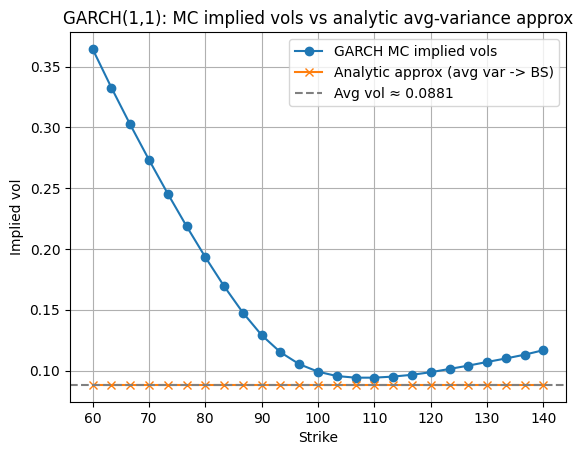

MC prices (first 5): [40.61346174 37.31378325 34.01473763 30.71698293 27.42133112]
MC implied vols (first 5): [0.3646479853628156, 0.3328460495627135, 0.30250884889294377, 0.27347381319004593, 0.245591900420994]
Analytic approx vol (annual): 0.08814914325736911
Expected avg variance (annual): 0.007770271457008183


'\nLimitations & next steps:\n\n* The "analytic" method here (plug-in sqrt(E[avg variance])) is a rough approximation.\n* For an exact closed-form under a GARCH process, consider the Heston-Nandi (2000) GARCH\n  model which provides semi-closed form option prices (via characteristic functions).\n  Implementing Heston-Nandi is possible but longer; I can provide it if you want an\n  accurate analytic benchmark under a proper risk-neutral GARCH transform.\n* You may also improve Monte Carlo by using antithetic sampling, control variates, or\n  using the same Gaussian draws to reduce noise when computing prices across strikes.\n'

In [5]:
"""
GARCH(1,1) option pricing: Monte Carlo simulation + analytic approximation

This module contains:

* simulate_garch_mc: Monte Carlo simulator for a GARCH(1,1) equity model under
  the (approximate) risk-neutral measure that simulates S_t and h_t (variance).
* price_options_mc: use the simulated terminal S_T to compute European call prices
  across strikes and invert to implied vols (Black).
* garch_expected_avg_vol: analytic forecast of the average variance over [0,T]
  under GARCH(1,1) and a simple Black approximation: implied vol ≈ sqrt( expected
  time-average variance ).
* helpers: Black call price and implied vol inverter.

Notes & assumptions:

* This is a pragmatic implementation intended for exploration/comparison with SABR.
* We simulate log-returns using the usual GARCH discrete-time update:
  h_{t+1} = omega + alpha * (z_t^2) * h_t + beta * h_t
  where z_t ~ N(0,1), and returns:
  r_{t+1} = (r - 0.5 * h_{t+1}) + sqrt(h_{t+1}) * z_{t+1}
  This is a commonly used discretization (Volatility used in next step).
* For risk-neutral pricing one should calibrate a risk premium / change-of-measure.
  Here we simply set the drift equal to the risk-free rate `r` (i.e., use RN drift).
  This is an approximation — for production you may want Heston-Nandi or other
  risk-neutral parameter transforms.
* The "analytic" solution provided here is an approximation: compute the expected
  time-average variance under GARCH and plug sqrt(E[var_avg]) into Black formula.
  This gives a quick analytic benchmark but is not exact for GARCH option prices.
  """

import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

def black_call_price(F, K, T, sigma, r=0.0):
    """Black-style call price for forward F (or underlying S with discounting already applied).
    If F is spot S0 and r is risk-free, use call = exp(-rT) * [S0 * N(d1) - K * N(d2)]."""
    if sigma <= 0 or T <= 0:
        return max(np.exp(-r*T) * max(F - K, 0.0), 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def implied_vol_from_price(price, F, K, T, r=0.0, sigma_low=1e-6, sigma_high=5.0):
    """Invert Black call price to implied vol. Return np.nan if inversion fails."""
    intrinsic = np.exp(-r*T) * max(F - K, 0.0)
    price = max(price, intrinsic + 1e-12)
    def f(sigma):
        return black_call_price(F, K, T, sigma, r) - price
    try:
        return brentq(f, sigma_low, sigma_high)
    except ValueError:
        return np.nan

def simulate_garch_mc(S0=100.0, r=0.0, T=1.0, steps=252, N=20000,
    omega=1e-6, alpha=0.05, beta=0.9, h0=0.01, seed=None):
    """
    Monte Carlo simulation of returns with a GARCH(1,1) variance process.
    
    ```
    Parameters
    ----------
    S0 : initial spot / forward level.
    r  : continuously compounded risk-free rate (used as drift under RN approximation).
    T  : maturity in years.
    steps : number of time steps (e.g., 252).
    N  : number of Monte Carlo paths.
    omega, alpha, beta : GARCH(1,1) parameters (variance equation).
    h0 : initial variance (annualized).
    seed : RNG seed.
    
    Returns
    -------
    S_paths : array shape (steps+1, N) of simulated spot levels (first row = S0)
    h_paths : array shape (steps+1, N) of simulated variances (first row = h0)
    """
    if seed is not None:
        np.random.seed(seed)
    dt = T / steps
    # use per-step variance (annualized -> per step)
    h_paths = np.empty((steps+1, N))
    S_paths = np.empty((steps+1, N))
    h_paths[0, :] = h0
    S_paths[0, :] = S0
    
    # simulate
    for t in range(1, steps+1):
        # draw z_t for variance update and returns (we use same z for simplicity)
        z = np.random.normal(0.0, 1.0, size=N)
        # GARCH update for one-step-ahead variance (annualized). We treat observations as squared standardized shocks
        # Note: Some implementations use epsilon_t = sqrt(h_t) * z_t and update with epsilon_t^2; here we use z^2 * h_t
        h_next = omega + alpha * (h_paths[t-1, :] * (z ** 2)) + beta * h_paths[t-1, :]
        # ensure non-negative
        h_next = np.maximum(h_next, 1e-12)
        # log-return: risk-neutral drift approx r - 0.5*h_next*dt, and diffusion sqrt(h_next*dt)
        # Note: h_next is annual variance; multiply by dt to get per-step variance
        vol_step = np.sqrt(h_next * dt)
        drift_step = (r - 0.5 * h_next) * dt  # using h_next (annual) in drift multiplier
        z2 = np.random.normal(0.0, 1.0, size=N)  # new shocks for returns
        log_ret = drift_step + vol_step * z2
        S_next = S_paths[t-1, :] * np.exp(log_ret)
        S_paths[t, :] = S_next
        h_paths[t, :] = h_next
    
    return S_paths, h_paths


def price_options_mc(S_paths, strikes, r, T):
    """
    Given simulated S_paths (steps+1, N), compute discounted European call prices for each strike.
    Returns list of prices (len = len(strikes)).
    """
    S_T = S_paths[-1, :]
    discounted = np.exp(-r * T)
    prices = []
    for K in strikes:
        payoffs = np.maximum(S_T - K, 0.0)
        prices.append(discounted * np.mean(payoffs))
    return np.array(prices)

def garch_expected_avg_vol(omega, alpha, beta, h0, steps, T):
    """
    Analytic forecast of the expected time-average variance over [0,T] for GARCH(1,1).
    We compute E[ (1/T) * \int_0^T h(t) dt ] ≈ average of 1-step forecasts.
    
    ```
    For discrete steps: compute forecasts h_{1},...,h_{steps} under the GARCH recursion
    taking expectations (replacing z^2 with 1 in expectation):
      E[h_{t+1}] = omega + (alpha + beta) * E[h_t]
    Solve recursion in closed form and average.
    
    Returns:
      var_avg = expected time-average variance (annualized)
      implied_vol_approx = sqrt(var_avg)  (annualized)
    """
    # solve E[h_t] recursion: m_{t+1} = omega + (alpha+beta) * m_t
    phi = alpha + beta
    # initial expected variance m0 = h0
    m = h0
    m_list = []
    for t in range(1, steps+1):
        m = omega + phi * m
        m_list.append(m)
    m_arr = np.array(m_list)
    # time-average (discrete) expectation of variance over steps -> annualized
    var_avg = m_arr.mean()
    implied_vol_approx = np.sqrt(var_avg)
    return var_avg, implied_vol_approx


# Example end-to-end: simulate, price across strikes, invert implied vols, compare with analytic approx

# if **name** == "**main**":
import matplotlib.pyplot as plt


# Model parameters (example)
S0 = 100.0
r = 0.01
T = 1.0
steps = 252
N = 40000

# GARCH(1,1) parameters (annualized)
omega = 1e-6
alpha = 0.08
beta = 0.9
h0 = 0.04  # initial variance ~ (20%)^2

# strikes
strikes = np.linspace(60, 140, 25)

# Monte Carlo
S_paths, h_paths = simulate_garch_mc(S0=S0, r=r, T=T, steps=steps, N=N,
                                     omega=omega, alpha=alpha, beta=beta, h0=h0, seed=123)
mc_prices = price_options_mc(S_paths, strikes, r, T)
mc_implied_vols = [implied_vol_from_price(p, S0, K, T, r) for p, K in zip(mc_prices, strikes)]

# Analytic approx: expected average variance and Black implied vol approx
var_avg, vol_approx = garch_expected_avg_vol(omega, alpha, beta, h0, steps, T)
analytic_prices = [black_call_price(S0, K, T, vol_approx, r) for K in strikes]
analytic_implied_vols = [implied_vol_from_price(p, S0, K, T, r) for p, K in zip(analytic_prices, strikes)]

# Plot implied vol smiles
plt.plot(strikes, mc_implied_vols, marker='o', label='GARCH MC implied vols')
plt.plot(strikes, analytic_implied_vols, marker='x', label='Analytic approx (avg var -> BS)')
plt.axhline(vol_approx, color='gray', linestyle='--', label=f'Avg vol ≈ {vol_approx:.4f}')
plt.xlabel("Strike")
plt.ylabel("Implied vol")
plt.title("GARCH(1,1): MC implied vols vs analytic avg-variance approx")
plt.legend()
plt.grid(True)
plt.show()

# Print a few diagnostics
print("MC prices (first 5):", mc_prices[:5])
print("MC implied vols (first 5):", mc_implied_vols[:5])
print("Analytic approx vol (annual):", vol_approx)
print("Expected avg variance (annual):", var_avg)


"""
Limitations & next steps:

* The "analytic" method here (plug-in sqrt(E[avg variance])) is a rough approximation.
* For an exact closed-form under a GARCH process, consider the Heston-Nandi (2000) GARCH
  model which provides semi-closed form option prices (via characteristic functions).
  Implementing Heston-Nandi is possible but longer; I can provide it if you want an
  accurate analytic benchmark under a proper risk-neutral GARCH transform.
* You may also improve Monte Carlo by using antithetic sampling, control variates, or
  using the same Gaussian draws to reduce noise when computing prices across strikes.
"""
